In [1]:
# CELL 1: cài thư viện
# Không dùng --upgrade pandas/pillow để tránh xung đột Colab.

!pip -q install ultralytics pandas==2.2.2 pillow==11.3.0 scikit-learn matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.3 MB/s eta 0:00:00


In [2]:
# CELL 2: mount Drive và khai báo cấu hình chính

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

from pathlib import Path

# ============================================================
# CHỌN MODEL MUỐN TEST Ở ĐÂY
# ============================================================

# Có thể để nhiều model. Code sẽ tự bỏ qua model nào chưa có checkpoint.
SELECTED_YOLO_ALIASES = ["YOLOv11n", "YOLOv11s", "YOLOv11m"]
SELECTED_CNN_ALIASES  = ["EfficientNetB0", "EfficientNetB1", "EfficientNetB2"]

# Nếu muốn test nhanh trước, đặt số nhỏ như 30.
# Nếu muốn test full, để None.
MAX_TEST_IMAGES = None
# MAX_TEST_IMAGES = 30

# Lưu ảnh minh họa prediction.
SAVE_ANNOTATED_IMAGES = True
SAVE_ANNOTATED_LIMIT = 80

# Cách vote cuối cùng: "weighted" hoặc "majority"
AGG_METHOD = "weighted"

# ============================================================
# PROJECT PATH
# ============================================================

MANUAL_PROJECT_ROOT = None
# Ví dụ nếu cần:
# MANUAL_PROJECT_ROOT = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification")

PROJECT_NAME = "Papaya_Leaf_Disease_Classification"

def find_project_root():
    if MANUAL_PROJECT_ROOT is not None:
        manual = Path(MANUAL_PROJECT_ROOT)
        if manual.exists():
            return manual
        raise FileNotFoundError(f"MANUAL_PROJECT_ROOT không tồn tại: {manual}")

    candidates = [
        Path("/content/drive/MyDrive") / PROJECT_NAME,
    ]

    for c in candidates:
        if c.exists():
            return c

    # Fallback cho trường hợp project nằm trong shortcut/shared folder.
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/.shortcut-targets-by-id"),
    ]

    for root in search_roots:
        if root.exists():
            found = list(root.rglob(PROJECT_NAME))
            for p in found:
                if p.is_dir() and (p / "prepared_data_v1").exists():
                    return p

    raise FileNotFoundError(
        "Không tìm thấy project root. Hãy kiểm tra Drive đã mount chưa hoặc set MANUAL_PROJECT_ROOT."
    )

PROJECT_ROOT = find_project_root()

PREP_ROOT = PROJECT_ROOT / "prepared_data_v1"
YOLO_DATASET_ROOT = PREP_ROOT / "yolo_dataset"
YOLO_IMAGES_TEST = YOLO_DATASET_ROOT / "images" / "test"
YOLO_LABELS_TEST = YOLO_DATASET_ROOT / "labels" / "test"
DATA_YAML = YOLO_DATASET_ROOT / "dataset.yaml"

CNN_DATASET_ROOT = PREP_ROOT / "cnn_dataset"
CNN_HEALTHY_TEST = CNN_DATASET_ROOT / "test" / "Healthy"

MODEL_ROOT = PROJECT_ROOT / "Model"
YOLO_MODEL_ROOT = MODEL_ROOT / "YOLOv11"
CNN_MODEL_ROOT = MODEL_ROOT / "CNN"

PIPELINE_ROOT = PROJECT_ROOT / "Model" / "Pipeline_Evaluation"
PIPELINE_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT      :", PROJECT_ROOT)
print("YOLO_DATASET_ROOT :", YOLO_DATASET_ROOT)
print("CNN_DATASET_ROOT  :", CNN_DATASET_ROOT)
print("YOLO_MODEL_ROOT   :", YOLO_MODEL_ROOT)
print("CNN_MODEL_ROOT    :", CNN_MODEL_ROOT)
print("PIPELINE_ROOT     :", PIPELINE_ROOT)

assert YOLO_IMAGES_TEST.exists(), f"Không thấy YOLO_IMAGES_TEST: {YOLO_IMAGES_TEST}"
assert YOLO_LABELS_TEST.exists(), f"Không thấy YOLO_LABELS_TEST: {YOLO_LABELS_TEST}"
assert CNN_HEALTHY_TEST.exists(), f"Không thấy CNN_HEALTHY_TEST: {CNN_HEALTHY_TEST}"

Mounted at /content/drive
PROJECT_ROOT      : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification
YOLO_DATASET_ROOT : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset
CNN_DATASET_ROOT  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/cnn_dataset
YOLO_MODEL_ROOT   : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11
CNN_MODEL_ROOT    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN
PIPELINE_ROOT     : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation


In [3]:
# CELL 3: import thư viện và cấu hình inference

import os
import re
import json
import time
import math
import random
import shutil
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

import torch
import tensorflow as tf
from tensorflow import keras

from ultralytics import YOLO
from tqdm.auto import tqdm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ============================================================
# CLASS CONFIG
# ============================================================

YOLO_CLASS_NAMES = ["Anthracnose", "BacterialSpot", "Curl", "RingSpot"]
CNN_CLASS_NAMES  = ["Anthracnose", "BacterialSpot", "Curl", "Healthy", "RingSpot"]
ALL_CLASS_NAMES  = CNN_CLASS_NAMES

YOLO_ID_TO_CLASS = {i: name for i, name in enumerate(YOLO_CLASS_NAMES)}
YOLO_CLASS_TO_ID = {name: i for i, name in YOLO_ID_TO_CLASS.items()}

CNN_ID_TO_CLASS = {i: name for i, name in enumerate(CNN_CLASS_NAMES)}
CNN_CLASS_TO_ID = {name: i for i, name in CNN_ID_TO_CLASS.items()}

# ============================================================
# CNN MODEL SPECS
# ============================================================

CNN_SPECS = {
    "EfficientNetB0": {"img_size": 224},
    "EfficientNetB1": {"img_size": 240},
    "EfficientNetB2": {"img_size": 260},
}

# ============================================================
# YOLO CONFIG
# ============================================================

YOLO_IMGSZ = 832
YOLO_IOU = 0.70

# Logic retry:
# 1. chạy YOLO ở conf cao
# 2. nếu không có bbox, đưa full image vào CNN
# 3. nếu CNN full image dự đoán bệnh, giảm conf YOLO dần tới min
# 4. nếu vẫn không có bbox, kết luận Healthy
YOLO_CONF_START = 0.50
YOLO_CONF_MIN = 0.35
YOLO_CONF_STEP = 0.05

# Nếu full-image CNN dự đoán bệnh nhưng confidence quá thấp, vẫn kết luận Healthy.
FULL_CNN_DISEASE_MIN_PROB = 0.50

# Crop mở rộng bbox để giữ thêm ngữ cảnh.
BBOX_EXPAND_RATIO = 0.10
MIN_CROP_SIZE = 8

# Device
TORCH_DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Torch CUDA available:", torch.cuda.is_available())
print("TORCH_DEVICE        :", TORCH_DEVICE)
print("TensorFlow version  :", tf.__version__)
print("ALL_CLASS_NAMES     :", ALL_CLASS_NAMES)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch CUDA available: True
TORCH_DEVICE        : 0
TensorFlow version  : 2.19.0
ALL_CLASS_NAMES     : ['Anthracnose', 'BacterialSpot', 'Curl', 'Healthy', 'RingSpot']


In [ ]:
# Find YOLO and CNN checkpoints in either Model/ or outputs/.
YOLO_DIR_ALIASES = {
    'YOLOv11n': ['YOLOv11n', 'yolov11_n', 'yolov11n'],
    'YOLOv11s': ['YOLOv11s', 'yolov11_s', 'yolov11s'],
    'YOLOv11m': ['YOLOv11m', 'yolov11_m', 'yolov11m'],
}
CNN_FILE_PRIORITY = ['best_model.keras', 'best_stage2.keras', 'last_stage2.keras', 'best_stage1.keras', 'last_stage1.keras']

def normalized(path):
    return str(path).lower().replace('_', '').replace('-', '').replace(' ', '')

def find_yolo_checkpoint(alias):
    candidates = []
    for alias_dir in YOLO_DIR_ALIASES.get(alias, [alias]):
        candidates.extend([
            YOLO_MODEL_ROOT / alias_dir / 'weights' / 'best.pt',
            YOLO_MODEL_ROOT / alias_dir / 'weights' / 'last.pt',
            PROJECT_ROOT / 'outputs' / 'yolo' / alias_dir.lower() / 'weights' / 'best.pt',
            PROJECT_ROOT / 'outputs' / 'yolo' / alias_dir.lower() / 'weights' / 'last.pt',
        ])
    for path in candidates:
        if path.is_file():
            return path
    key = normalized(alias)
    found = [p for p in PROJECT_ROOT.rglob('*.pt') if key in normalized(p) and p.name in {'best.pt', 'last.pt'}]
    for name in ['best.pt', 'last.pt']:
        matches = sorted(p for p in found if p.name == name)
        if matches:
            return matches[0]
    return None

def find_cnn_checkpoint(alias):
    run_dir = CNN_MODEL_ROOT / alias
    for name in CNN_FILE_PRIORITY:
        candidate = run_dir / name
        if candidate.is_file():
            return candidate
    key = normalized(alias)
    found = [p for p in PROJECT_ROOT.rglob('*.keras') if key in normalized(p) and p.name in CNN_FILE_PRIORITY]
    for name in CNN_FILE_PRIORITY:
        matches = sorted(p for p in found if p.name == name)
        if matches:
            return matches[0]
    return None

available_yolo = {alias: find_yolo_checkpoint(alias) for alias in SELECTED_YOLO_ALIASES}
available_yolo = {alias: path for alias, path in available_yolo.items() if path is not None}
available_cnn = {alias: find_cnn_checkpoint(alias) for alias in SELECTED_CNN_ALIASES}
available_cnn = {alias: path for alias, path in available_cnn.items() if path is not None}

print('===== AVAILABLE YOLO CHECKPOINTS =====')
for alias, path in available_yolo.items():
    print(alias, '=>', path)
print('\n===== AVAILABLE CNN CHECKPOINTS =====')
for alias, path in available_cnn.items():
    print(alias, '=>', path)

assert available_yolo, f'No YOLO checkpoints found under {PROJECT_ROOT}/Model or {PROJECT_ROOT}/outputs.'
assert available_cnn, f'No CNN checkpoints found under {PROJECT_ROOT}/Model or {PROJECT_ROOT}/outputs.'


In [5]:
# CELL 5: tạo tập test 5 lớp
# Mục đích:
# - 4 lớp bệnh lấy từ YOLO test images + YOLO test labels
# - Healthy lấy từ CNN test/Healthy
# - Tạo DataFrame test_df gồm image_path, true_class, source

VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(folder):
    folder = Path(folder)
    return sorted([
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
    ])

def parse_yolo_label_file(label_path):
    label_path = Path(label_path)
    if not label_path.exists():
        return []

    cls_ids = []
    with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            try:
                cls_id = int(float(parts[0]))
                if cls_id in YOLO_ID_TO_CLASS:
                    cls_ids.append(cls_id)
            except Exception:
                pass

    return cls_ids

def infer_true_class_from_yolo_label(label_path):
    cls_ids = parse_yolo_label_file(label_path)
    if len(cls_ids) == 0:
        return None

    most_common_id = Counter(cls_ids).most_common(1)[0][0]
    return YOLO_ID_TO_CLASS[most_common_id]

test_records = []

# Disease test từ YOLO
for img_path in list_images(YOLO_IMAGES_TEST):
    lbl_path = YOLO_LABELS_TEST / f"{img_path.stem}.txt"
    true_class = infer_true_class_from_yolo_label(lbl_path)

    if true_class is None:
        continue

    test_records.append({
        "image_path": str(img_path),
        "true_class": true_class,
        "source": "yolo_test_disease",
        "label_path": str(lbl_path),
    })

# Healthy test từ CNN
for img_path in list_images(CNN_HEALTHY_TEST):
    test_records.append({
        "image_path": str(img_path),
        "true_class": "Healthy",
        "source": "cnn_test_healthy",
        "label_path": None,
    })

test_df = pd.DataFrame(test_records)

if MAX_TEST_IMAGES is not None:
    test_df = (
        test_df
        .groupby("true_class", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), max(1, MAX_TEST_IMAGES // len(ALL_CLASS_NAMES))), random_state=SEED))
        .reset_index(drop=True)
    )

test_df = test_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

test_df.to_csv(PIPELINE_ROOT / "pipeline_test_manifest.csv", index=False, encoding="utf-8-sig")

print("Total test images:", len(test_df))
display(test_df.groupby(["source", "true_class"]).size().reset_index(name="count"))
display(test_df.head())

Total test images: 291


,source,true_class,count
0,cnn_test_healthy,Healthy,34
1,yolo_test_disease,Anthracnose,54
2,yolo_test_disease,BacterialSpot,69
3,yolo_test_disease,Curl,54
4,yolo_test_disease,RingSpot,80


,image_path,true_class,source,label_path
0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Healthy,cnn_test_healthy,None
2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Anthracnose,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
3,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Curl,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...
4,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Curl,yolo_test_disease,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...


In [6]:
# CELL 6: hàm xử lý ảnh, crop bbox, CNN predict, YOLO predict

def safe_json_dumps(obj):
    try:
        return json.dumps(obj, ensure_ascii=False)
    except Exception:
        return str(obj)

def load_pil_rgb(image_path):
    return Image.open(image_path).convert("RGB")

def clamp_box(x1, y1, x2, y2, w, h):
    x1 = max(0, min(int(round(x1)), w - 1))
    y1 = max(0, min(int(round(y1)), h - 1))
    x2 = max(1, min(int(round(x2)), w))
    y2 = max(1, min(int(round(y2)), h))

    if x2 <= x1:
        x2 = min(w, x1 + 1)
    if y2 <= y1:
        y2 = min(h, y1 + 1)

    return x1, y1, x2, y2

def expand_xyxy(box, image_w, image_h, expand_ratio=0.10):
    x1, y1, x2, y2 = box
    bw = x2 - x1
    bh = y2 - y1

    ex = bw * expand_ratio
    ey = bh * expand_ratio

    return clamp_box(
        x1 - ex,
        y1 - ey,
        x2 + ex,
        y2 + ey,
        image_w,
        image_h,
    )

def crop_from_box(pil_img, box_xyxy, expand_ratio=0.10):
    w, h = pil_img.size
    x1, y1, x2, y2 = expand_xyxy(box_xyxy, w, h, expand_ratio)

    if (x2 - x1) < MIN_CROP_SIZE or (y2 - y1) < MIN_CROP_SIZE:
        return None, (x1, y1, x2, y2)

    return pil_img.crop((x1, y1, x2, y2)), (x1, y1, x2, y2)

def cnn_predict_pil(cnn_model, pil_img, img_size):
    img = pil_img.resize((img_size, img_size))
    arr = np.asarray(img).astype("float32")
    arr = np.expand_dims(arr, axis=0)

    probs = cnn_model.predict(arr, verbose=0)[0]
    pred_id = int(np.argmax(probs))
    pred_class = CNN_ID_TO_CLASS[pred_id]
    pred_conf = float(probs[pred_id])

    return pred_class, pred_conf, probs.astype(float).tolist()

def yolo_detect_once(yolo_model, image_path, conf):
    results = yolo_model.predict(
        source=str(image_path),
        imgsz=YOLO_IMGSZ,
        conf=conf,
        iou=YOLO_IOU,
        device=TORCH_DEVICE,
        verbose=False,
    )

    r = results[0]
    boxes = []

    if r.boxes is None or len(r.boxes) == 0:
        return boxes

    for b in r.boxes:
        xyxy = b.xyxy.detach().cpu().numpy()[0].tolist()
        cls_id = int(b.cls.detach().cpu().numpy()[0])
        yolo_conf = float(b.conf.detach().cpu().numpy()[0])

        if cls_id not in YOLO_ID_TO_CLASS:
            continue

        boxes.append({
            "xyxy": [float(v) for v in xyxy],
            "yolo_class_id": cls_id,
            "yolo_class": YOLO_ID_TO_CLASS[cls_id],
            "yolo_conf": yolo_conf,
        })

    boxes = sorted(boxes, key=lambda x: x["yolo_conf"], reverse=True)
    return boxes

def conf_sequence(start=0.50, min_conf=0.35, step=0.05):
    vals = []
    c = start
    while c >= min_conf - 1e-9:
        vals.append(round(c, 3))
        c -= step
    return vals

In [7]:
# CELL 7: hàm hybrid pipeline YOLO → crop → CNN → vote

def aggregate_crop_predictions(crop_preds, method="weighted"):
    """
    crop_preds: list dict gồm cnn_class, cnn_conf, yolo_conf
    """
    if len(crop_preds) == 0:
        return "Healthy", {}, []

    scores = {cls: 0.0 for cls in ALL_CLASS_NAMES}

    if method == "majority":
        votes = Counter([p["cnn_class"] for p in crop_preds])
        max_vote = max(votes.values())
        candidates = [cls for cls, cnt in votes.items() if cnt == max_vote]

        # tie-break bằng weighted score
        weighted_scores = defaultdict(float)
        for p in crop_preds:
            weighted_scores[p["cnn_class"]] += p["cnn_conf"] * p["yolo_conf"]

        pred_class = sorted(
            candidates,
            key=lambda cls: weighted_scores.get(cls, 0.0),
            reverse=True
        )[0]

        for cls, cnt in votes.items():
            scores[cls] = float(cnt)

    else:
        for p in crop_preds:
            cls = p["cnn_class"]
            scores[cls] += float(p["cnn_conf"]) * float(p["yolo_conf"])

        pred_class = max(scores, key=scores.get)

    disease_list = []
    for p in crop_preds:
        if p["cnn_class"] != "Healthy":
            disease_list.append({
                "class": p["cnn_class"],
                "cnn_conf": p["cnn_conf"],
                "yolo_conf": p["yolo_conf"],
                "score": p["cnn_conf"] * p["yolo_conf"],
            })

    disease_list = sorted(disease_list, key=lambda x: x["score"], reverse=True)
    return pred_class, scores, disease_list

def run_hybrid_on_image(image_path, yolo_model, cnn_model, cnn_img_size):
    image_path = Path(image_path)
    pil_img = load_pil_rgb(image_path)

    result = {
        "image_path": str(image_path),
        "pred_class": None,
        "reason": None,
        "num_boxes": 0,
        "conf_used": None,
        "full_cnn_class": None,
        "full_cnn_conf": None,
        "boxes": [],
        "crop_predictions": [],
        "final_scores": {},
        "disease_list": [],
        "error": None,
    }

    try:
        # 1. YOLO ở confidence ban đầu
        boxes = yolo_detect_once(yolo_model, image_path, conf=YOLO_CONF_START)
        conf_used = YOLO_CONF_START

        # 2. Nếu không có bbox, dùng CNN full-image để quyết định có retry YOLO không
        if len(boxes) == 0:
            full_cls, full_conf, full_probs = cnn_predict_pil(cnn_model, pil_img, cnn_img_size)
            result["full_cnn_class"] = full_cls
            result["full_cnn_conf"] = full_conf

            if full_cls == "Healthy" or full_conf < FULL_CNN_DISEASE_MIN_PROB:
                result["pred_class"] = "Healthy"
                result["reason"] = "no_yolo_box_full_cnn_healthy_or_low_conf"
                result["num_boxes"] = 0
                result["conf_used"] = YOLO_CONF_START
                return result

            # 3. Full CNN dự đoán bệnh, giảm conf YOLO dần
            retry_confs = conf_sequence(
                start=YOLO_CONF_START - YOLO_CONF_STEP,
                min_conf=YOLO_CONF_MIN,
                step=YOLO_CONF_STEP
            )

            for c in retry_confs:
                boxes = yolo_detect_once(yolo_model, image_path, conf=c)
                if len(boxes) > 0:
                    conf_used = c
                    break

            # 4. Nếu giảm tới min vẫn không có bbox, theo logic của bạn: kết luận Healthy
            if len(boxes) == 0:
                result["pred_class"] = "Healthy"
                result["reason"] = "no_yolo_box_after_conf_retry"
                result["num_boxes"] = 0
                result["conf_used"] = YOLO_CONF_MIN
                return result

        # 5. Có bbox thì crop từng bbox và đưa vào CNN
        crop_preds = []

        for idx, box in enumerate(boxes):
            crop_img, expanded_box = crop_from_box(
                pil_img,
                box["xyxy"],
                expand_ratio=BBOX_EXPAND_RATIO
            )

            if crop_img is None:
                continue

            cnn_cls, cnn_conf, cnn_probs = cnn_predict_pil(
                cnn_model,
                crop_img,
                cnn_img_size
            )

            crop_pred = {
                "box_index": idx,
                "xyxy": [float(v) for v in box["xyxy"]],
                "expanded_xyxy": [float(v) for v in expanded_box],
                "yolo_class": box["yolo_class"],
                "yolo_conf": float(box["yolo_conf"]),
                "cnn_class": cnn_cls,
                "cnn_conf": float(cnn_conf),
                "cnn_probs": cnn_probs,
            }
            crop_preds.append(crop_pred)

        if len(crop_preds) == 0:
            result["pred_class"] = "Healthy"
            result["reason"] = "boxes_exist_but_all_crops_invalid"
            result["num_boxes"] = len(boxes)
            result["conf_used"] = conf_used
            result["boxes"] = boxes
            return result

        final_cls, final_scores, disease_list = aggregate_crop_predictions(
            crop_preds,
            method=AGG_METHOD
        )

        result["pred_class"] = final_cls
        result["reason"] = f"yolo_boxes_cnn_{AGG_METHOD}_vote"
        result["num_boxes"] = len(boxes)
        result["conf_used"] = conf_used
        result["boxes"] = boxes
        result["crop_predictions"] = crop_preds
        result["final_scores"] = final_scores
        result["disease_list"] = disease_list

        return result

    except Exception as e:
        result["pred_class"] = "ERROR"
        result["reason"] = "exception"
        result["error"] = str(e)
        return result

In [8]:
# CELL 8: hàm vẽ ảnh minh họa prediction

def draw_prediction_image(image_path, pred_result, true_class, save_path):
    img = load_pil_rgb(image_path)
    draw = ImageDraw.Draw(img)

    pred_class = pred_result.get("pred_class", "NA")
    reason = pred_result.get("reason", "")

    title = f"GT: {true_class} | Pred: {pred_class} | {reason}"
    draw.rectangle([0, 0, img.size[0], 28], fill=(255, 255, 255))
    draw.text((5, 5), title, fill=(0, 0, 0))

    crop_preds = pred_result.get("crop_predictions", [])

    for p in crop_preds:
        x1, y1, x2, y2 = p["xyxy"]
        ex1, ey1, ex2, ey2 = p["expanded_xyxy"]

        # bbox YOLO gốc
        draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=3)

        # bbox expanded
        draw.rectangle([ex1, ey1, ex2, ey2], outline=(0, 255, 0), width=2)

        label = f"Y:{p['yolo_class']} {p['yolo_conf']:.2f} | CNN:{p['cnn_class']} {p['cnn_conf']:.2f}"
        ty = max(30, int(y1) - 18)
        draw.rectangle([x1, ty, min(img.size[0], x1 + 420), ty + 18], fill=(255, 255, 255))
        draw.text((x1 + 2, ty + 2), label, fill=(0, 0, 0))

    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    img.save(save_path)


EVALUATING PAIR: YOLOv11n__EfficientNetB0
YOLO: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n/weights/best.pt
CNN : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB0/best_model.keras


YOLOv11n__EfficientNetB0:   0%|          | 0/291 [00:00<?, ?it/s]

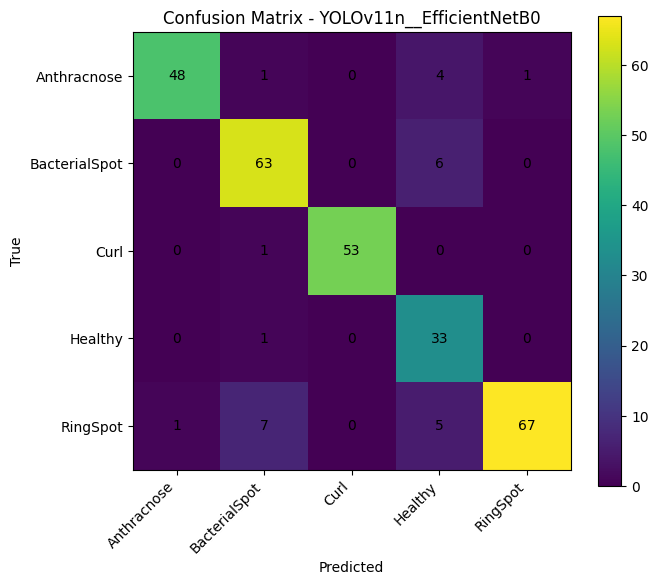


SUMMARY:
{
  "pair_name": "YOLOv11n__EfficientNetB0",
  "yolo_alias": "YOLOv11n",
  "cnn_alias": "EfficientNetB0",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB0/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9072164948453608,
  "macro_precision": 0.903079930602378,
  "macro_recall": 0.9183004167850715,
  "macro_f1": 0.9040600876813596,
  "weighted_precision": 0.9231767484567616,
  "weighted_recall": 0.9072164948453608,
  "weighted_f1": 0.910134235030335,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11n__EfficientNetB0/pipeline_predictions.csv",
  "pa

YOLOv11n__EfficientNetB1:   0%|          | 0/291 [00:00<?, ?it/s]

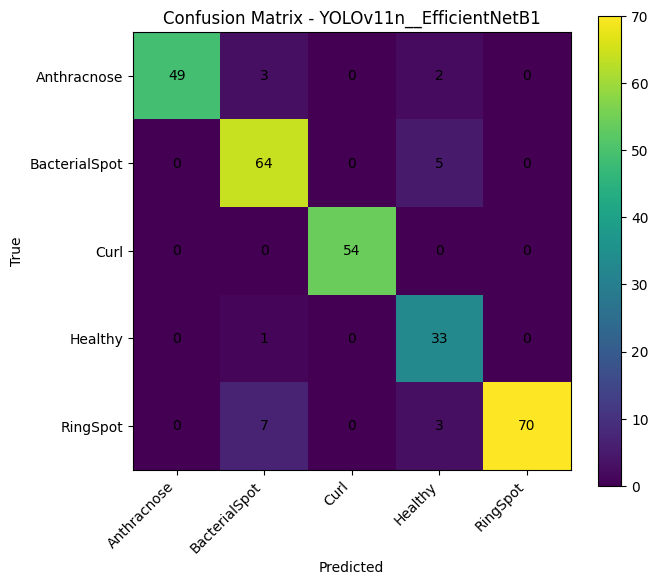


SUMMARY:
{
  "pair_name": "YOLOv11n__EfficientNetB1",
  "yolo_alias": "YOLOv11n",
  "cnn_alias": "EfficientNetB1",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB1/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9278350515463918,
  "macro_precision": 0.9241550387596899,
  "macro_recall": 0.9361063749171166,
  "macro_f1": 0.9261642780089382,
  "weighted_precision": 0.9380516263086389,
  "weighted_recall": 0.9278350515463918,
  "weighted_f1": 0.9296271406170316,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11n__EfficientNetB1/pipeline_predictions.csv",
  "

YOLOv11n__EfficientNetB2:   0%|          | 0/291 [00:00<?, ?it/s]

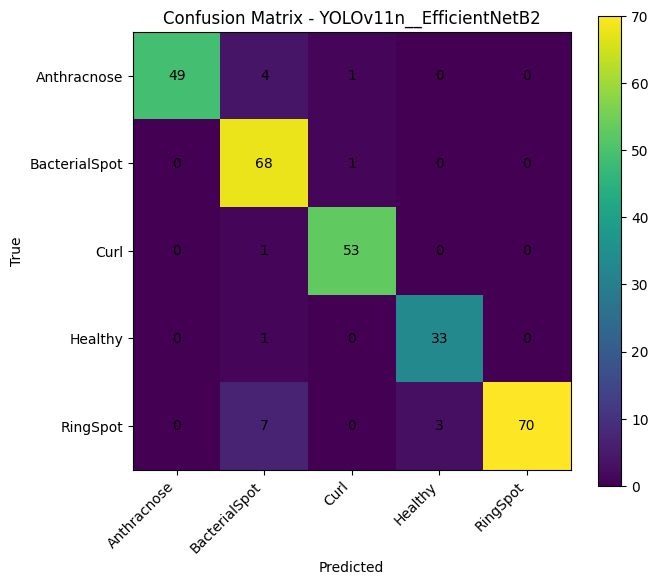


SUMMARY:
{
  "pair_name": "YOLOv11n__EfficientNetB2",
  "yolo_alias": "YOLOv11n",
  "cnn_alias": "EfficientNetB2",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB2/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9381443298969072,
  "macro_precision": 0.9439618406285073,
  "macro_recall": 0.9439968741119635,
  "macro_f1": 0.9413581035513877,
  "weighted_precision": 0.9454603306836983,
  "weighted_recall": 0.9381443298969072,
  "weighted_f1": 0.9387498686199259,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11n__EfficientNetB2/pipeline_predictions.csv",
  "

YOLOv11s__EfficientNetB0:   0%|          | 0/291 [00:00<?, ?it/s]

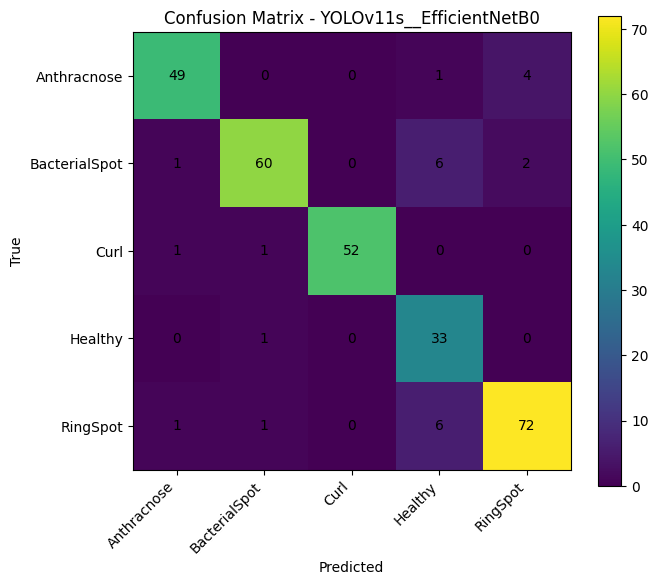


SUMMARY:
{
  "pair_name": "YOLOv11s__EfficientNetB0",
  "yolo_alias": "YOLOv11s",
  "cnn_alias": "EfficientNetB0",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11s/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB0/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9140893470790378,
  "macro_precision": 0.9070313744226788,
  "macro_recall": 0.9221047646111584,
  "macro_f1": 0.910228738302538,
  "weighted_precision": 0.9238362862298317,
  "weighted_recall": 0.9140893470790378,
  "weighted_f1": 0.9161317027824554,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11s__EfficientNetB0/pipeline_predictions.csv",
  "p

YOLOv11s__EfficientNetB1:   0%|          | 0/291 [00:00<?, ?it/s]

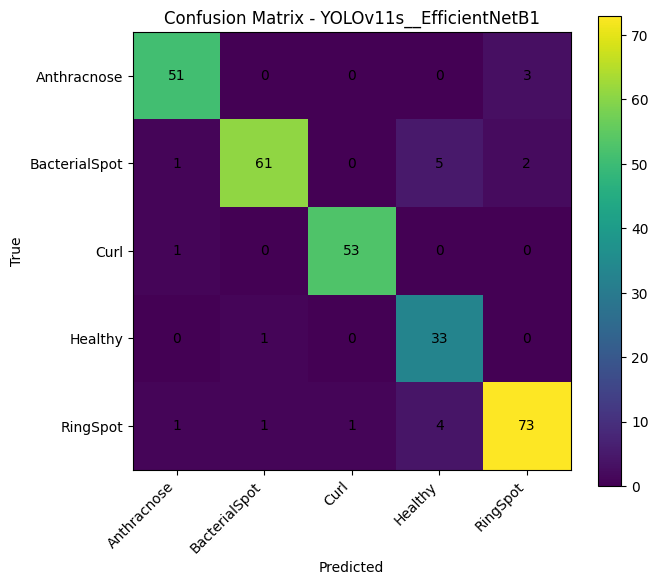


SUMMARY:
{
  "pair_name": "YOLOv11s__EfficientNetB1",
  "yolo_alias": "YOLOv11s",
  "cnn_alias": "EfficientNetB1",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11s/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB1/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9312714776632303,
  "macro_precision": 0.9231583231583231,
  "macro_recall": 0.9386144264469072,
  "macro_f1": 0.9285280071422644,
  "weighted_precision": 0.9360673690570597,
  "weighted_recall": 0.9312714776632303,
  "weighted_f1": 0.9320381226636162,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11s__EfficientNetB1/pipeline_predictions.csv",
  "

YOLOv11s__EfficientNetB2:   0%|          | 0/291 [00:00<?, ?it/s]

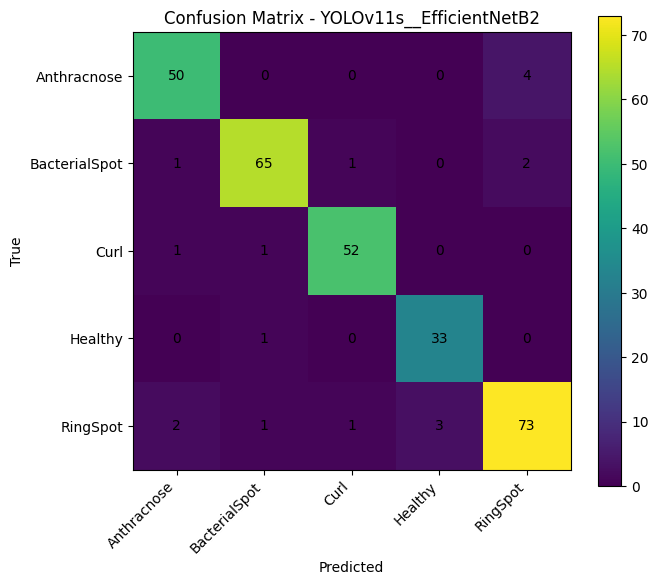


SUMMARY:
{
  "pair_name": "YOLOv11s__EfficientNetB2",
  "yolo_alias": "YOLOv11s",
  "cnn_alias": "EfficientNetB2",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11s/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB2/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9381443298969072,
  "macro_precision": 0.937097708281625,
  "macro_recall": 0.9428012219380506,
  "macro_f1": 0.939778026989155,
  "weighted_precision": 0.9383044661598599,
  "weighted_recall": 0.9381443298969072,
  "weighted_f1": 0.9381124223668134,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11s__EfficientNetB2/pipeline_predictions.csv",
  "pa

YOLOv11m__EfficientNetB0:   0%|          | 0/291 [00:00<?, ?it/s]

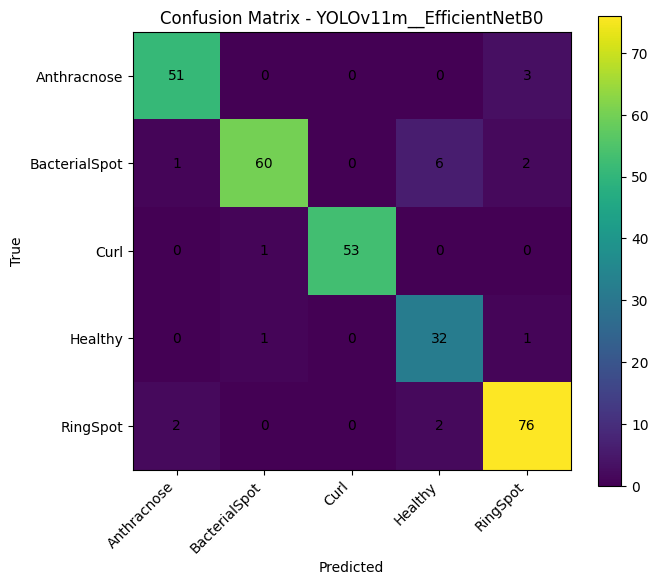


SUMMARY:
{
  "pair_name": "YOLOv11m__EfficientNetB0",
  "yolo_alias": "YOLOv11m",
  "cnn_alias": "EfficientNetB0",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB0/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9347079037800687,
  "macro_precision": 0.9278031296441996,
  "macro_recall": 0.9373335227810932,
  "macro_f1": 0.9308531308412406,
  "weighted_precision": 0.9385585395594561,
  "weighted_recall": 0.9347079037800687,
  "weighted_f1": 0.935287174479381,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11m__EfficientNetB0/pipeline_predictions.csv",
  "p

YOLOv11m__EfficientNetB1:   0%|          | 0/291 [00:00<?, ?it/s]

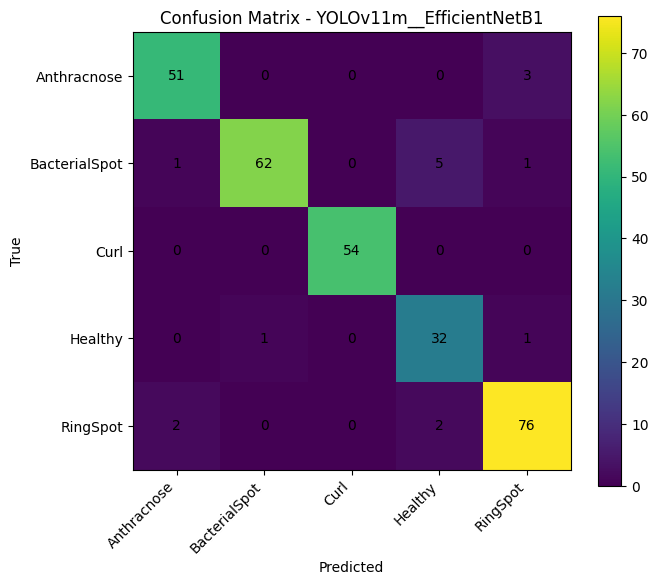


SUMMARY:
{
  "pair_name": "YOLOv11m__EfficientNetB1",
  "yolo_alias": "YOLOv11m",
  "cnn_alias": "EfficientNetB1",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB1/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9450171821305842,
  "macro_precision": 0.937471170804504,
  "macro_recall": 0.9468343279340722,
  "macro_f1": 0.940930018297499,
  "weighted_precision": 0.9479860006778678,
  "weighted_recall": 0.9450171821305842,
  "weighted_f1": 0.945547598992519,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11m__EfficientNetB1/pipeline_predictions.csv",
  "pai

YOLOv11m__EfficientNetB2:   0%|          | 0/291 [00:00<?, ?it/s]

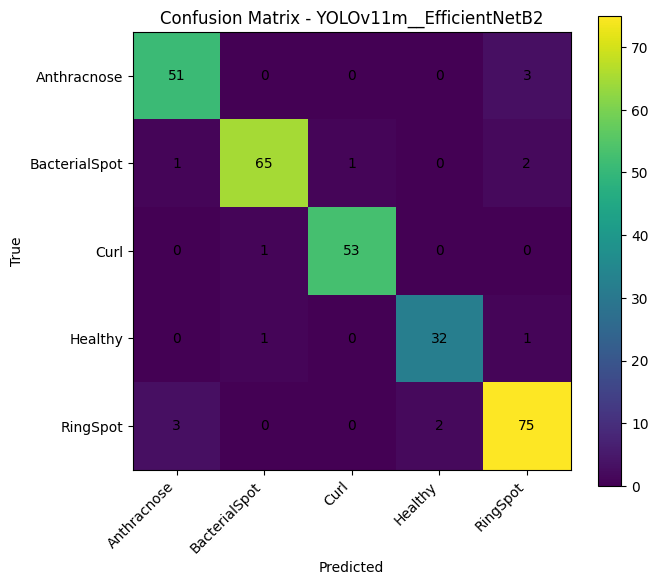


SUMMARY:
{
  "pair_name": "YOLOv11m__EfficientNetB2",
  "yolo_alias": "YOLOv11m",
  "cnn_alias": "EfficientNetB2",
  "yolo_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt",
  "cnn_ckpt": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/CNN/EfficientNetB2/best_model.keras",
  "num_test_images": 291,
  "num_valid_predictions": 291,
  "accuracy": 0.9484536082474226,
  "macro_precision": 0.9492011717999425,
  "macro_recall": 0.9493262764042815,
  "macro_f1": 0.949199428031639,
  "weighted_precision": 0.9487529204613884,
  "weighted_recall": 0.9484536082474226,
  "weighted_f1": 0.9485297386095105,
  "agg_method": "weighted",
  "yolo_conf_start": 0.5,
  "yolo_conf_min": 0.35,
  "yolo_conf_step": 0.05,
  "full_cnn_disease_min_prob": 0.5,
  "bbox_expand_ratio": 0.1,
  "result_csv": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11m__EfficientNetB2/pipeline_predictions.csv",
  "p

,pair_name,yolo_alias,cnn_alias,yolo_ckpt,cnn_ckpt,num_test_images,num_valid_predictions,accuracy,macro_precision,macro_recall,...,weighted_f1,agg_method,yolo_conf_start,yolo_conf_min,yolo_conf_step,full_cnn_disease_min_prob,bbox_expand_ratio,result_csv,pair_dir,timestamp
0,YOLOv11n__EfficientNetB0,YOLOv11n,EfficientNetB0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.907216,0.903080,0.918300,...,0.910134,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 10:55:08
1,YOLOv11n__EfficientNetB1,YOLOv11n,EfficientNetB1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.927835,0.924155,0.936106,...,0.929627,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 10:57:40
2,YOLOv11n__EfficientNetB2,YOLOv11n,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.938144,0.943962,0.943997,...,0.938750,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:00:12
3,YOLOv11s__EfficientNetB0,YOLOv11s,EfficientNetB0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.914089,0.907031,0.922105,...,0.916132,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:02:50
4,YOLOv11s__EfficientNetB1,YOLOv11s,EfficientNetB1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.931271,0.923158,0.938614,...,0.932038,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:05:34
5,YOLOv11s__EfficientNetB2,YOLOv11s,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.938144,0.937098,0.942801,...,0.938112,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:08:23
6,YOLOv11m__EfficientNetB0,YOLOv11m,EfficientNetB0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.934708,0.927803,0.937334,...,0.935287,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:11:10
7,YOLOv11m__EfficientNetB1,YOLOv11m,EfficientNetB1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.945017,0.937471,0.946834,...,0.945548,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:14:02
8,YOLOv11m__EfficientNetB2,YOLOv11m,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.948454,0.949201,0.949326,...,0.948530,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:16:54


In [9]:
# CELL 9: chạy evaluation cho từng cặp YOLO + CNN

def evaluate_pair(yolo_alias, yolo_ckpt, cnn_alias, cnn_ckpt):
    pair_name = f"{yolo_alias}__{cnn_alias}"
    pair_dir = PIPELINE_ROOT / pair_name
    pred_dir = pair_dir / "annotated_images"

    pair_dir.mkdir(parents=True, exist_ok=True)
    pred_dir.mkdir(parents=True, exist_ok=True)

    print("\n" + "=" * 100)
    print("EVALUATING PAIR:", pair_name)
    print("=" * 100)
    print("YOLO:", yolo_ckpt)
    print("CNN :", cnn_ckpt)

    yolo_model = YOLO(str(yolo_ckpt))
    cnn_model = keras.models.load_model(str(cnn_ckpt))
    cnn_img_size = CNN_SPECS[cnn_alias]["img_size"]

    rows = []
    annotated_count = 0

    for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc=pair_name):
        image_path = row["image_path"]
        true_class = row["true_class"]

        pred_result = run_hybrid_on_image(
            image_path=image_path,
            yolo_model=yolo_model,
            cnn_model=cnn_model,
            cnn_img_size=cnn_img_size
        )

        pred_class = pred_result.get("pred_class", "ERROR")
        correct = int(pred_class == true_class)

        out_row = {
            "pair_name": pair_name,
            "yolo_alias": yolo_alias,
            "cnn_alias": cnn_alias,
            "image_path": image_path,
            "true_class": true_class,
            "pred_class": pred_class,
            "correct": correct,
            "source": row["source"],
            "reason": pred_result.get("reason"),
            "num_boxes": pred_result.get("num_boxes"),
            "conf_used": pred_result.get("conf_used"),
            "full_cnn_class": pred_result.get("full_cnn_class"),
            "full_cnn_conf": pred_result.get("full_cnn_conf"),
            "final_scores_json": safe_json_dumps(pred_result.get("final_scores", {})),
            "disease_list_json": safe_json_dumps(pred_result.get("disease_list", [])),
            "crop_predictions_json": safe_json_dumps(pred_result.get("crop_predictions", [])),
            "error": pred_result.get("error"),
        }
        rows.append(out_row)

        if SAVE_ANNOTATED_IMAGES and annotated_count < SAVE_ANNOTATED_LIMIT:
            # Ưu tiên lưu ảnh sai + một số ảnh đúng
            should_save = (correct == 0) or (annotated_count < SAVE_ANNOTATED_LIMIT // 2)
            if should_save:
                status = "correct" if correct else "wrong"
                save_name = f"{idx:05d}_{status}_{true_class}_pred_{pred_class}.jpg"
                draw_prediction_image(
                    image_path=image_path,
                    pred_result=pred_result,
                    true_class=true_class,
                    save_path=pred_dir / save_name
                )
                annotated_count += 1

    result_df = pd.DataFrame(rows)
    result_csv = pair_dir / "pipeline_predictions.csv"
    result_df.to_csv(result_csv, index=False, encoding="utf-8-sig")

    # Metrics
    valid_df = result_df[result_df["pred_class"].isin(ALL_CLASS_NAMES)].copy()

    y_true = valid_df["true_class"].tolist()
    y_pred = valid_df["pred_class"].tolist()

    acc = accuracy_score(y_true, y_pred)

    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES,
        average="macro",
        zero_division=0
    )

    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES,
        average="weighted",
        zero_division=0
    )

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES,
        target_names=ALL_CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_df.to_csv(pair_dir / "classification_report.csv", encoding="utf-8-sig")

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=ALL_CLASS_NAMES
    )

    cm_df = pd.DataFrame(cm, index=ALL_CLASS_NAMES, columns=ALL_CLASS_NAMES)
    cm_df.to_csv(pair_dir / "confusion_matrix.csv", encoding="utf-8-sig")

    # Plot confusion matrix
    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title(f"Confusion Matrix - {pair_name}")
    plt.colorbar()

    ticks = np.arange(len(ALL_CLASS_NAMES))
    plt.xticks(ticks, ALL_CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(ticks, ALL_CLASS_NAMES)

    for i in range(len(ALL_CLASS_NAMES)):
        for j in range(len(ALL_CLASS_NAMES)):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(pair_dir / "confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    summary = {
        "pair_name": pair_name,
        "yolo_alias": yolo_alias,
        "cnn_alias": cnn_alias,
        "yolo_ckpt": str(yolo_ckpt),
        "cnn_ckpt": str(cnn_ckpt),
        "num_test_images": int(len(result_df)),
        "num_valid_predictions": int(len(valid_df)),
        "accuracy": float(acc),
        "macro_precision": float(macro_p),
        "macro_recall": float(macro_r),
        "macro_f1": float(macro_f1),
        "weighted_precision": float(weighted_p),
        "weighted_recall": float(weighted_r),
        "weighted_f1": float(weighted_f1),
        "agg_method": AGG_METHOD,
        "yolo_conf_start": YOLO_CONF_START,
        "yolo_conf_min": YOLO_CONF_MIN,
        "yolo_conf_step": YOLO_CONF_STEP,
        "full_cnn_disease_min_prob": FULL_CNN_DISEASE_MIN_PROB,
        "bbox_expand_ratio": BBOX_EXPAND_RATIO,
        "result_csv": str(result_csv),
        "pair_dir": str(pair_dir),
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    with open(pair_dir / "summary.json", "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)

    print("\nSUMMARY:")
    print(json.dumps(summary, indent=2, ensure_ascii=False))

    return summary, result_df

all_summaries = []

for yolo_alias, yolo_ckpt in available_yolo.items():
    for cnn_alias, cnn_ckpt in available_cnn.items():
        summary, _ = evaluate_pair(
            yolo_alias=yolo_alias,
            yolo_ckpt=yolo_ckpt,
            cnn_alias=cnn_alias,
            cnn_ckpt=cnn_ckpt
        )
        all_summaries.append(summary)

summary_df = pd.DataFrame(all_summaries)
summary_df.to_csv(PIPELINE_ROOT / "all_pipeline_summary.csv", index=False, encoding="utf-8-sig")

print("\n===== ALL PIPELINE SUMMARY =====")
display(summary_df)

,pair_name,yolo_alias,cnn_alias,yolo_ckpt,cnn_ckpt,num_test_images,num_valid_predictions,accuracy,macro_precision,macro_recall,...,weighted_f1,agg_method,yolo_conf_start,yolo_conf_min,yolo_conf_step,full_cnn_disease_min_prob,bbox_expand_ratio,result_csv,pair_dir,timestamp
0,YOLOv11m__EfficientNetB2,YOLOv11m,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.948454,0.949201,0.949326,...,0.948530,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:16:54
1,YOLOv11n__EfficientNetB2,YOLOv11n,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.938144,0.943962,0.943997,...,0.938750,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:00:12
2,YOLOv11m__EfficientNetB1,YOLOv11m,EfficientNetB1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.945017,0.937471,0.946834,...,0.945548,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:14:02
3,YOLOv11s__EfficientNetB2,YOLOv11s,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.938144,0.937098,0.942801,...,0.938112,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:08:23
4,YOLOv11m__EfficientNetB0,YOLOv11m,EfficientNetB0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.934708,0.927803,0.937334,...,0.935287,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:11:10
5,YOLOv11s__EfficientNetB1,YOLOv11s,EfficientNetB1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.931271,0.923158,0.938614,...,0.932038,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:05:34
6,YOLOv11n__EfficientNetB1,YOLOv11n,EfficientNetB1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.927835,0.924155,0.936106,...,0.929627,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 10:57:40
7,YOLOv11s__EfficientNetB0,YOLOv11s,EfficientNetB0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.914089,0.907031,0.922105,...,0.916132,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:02:50
8,YOLOv11n__EfficientNetB0,YOLOv11n,EfficientNetB0,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.907216,0.903080,0.918300,...,0.910134,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 10:55:08


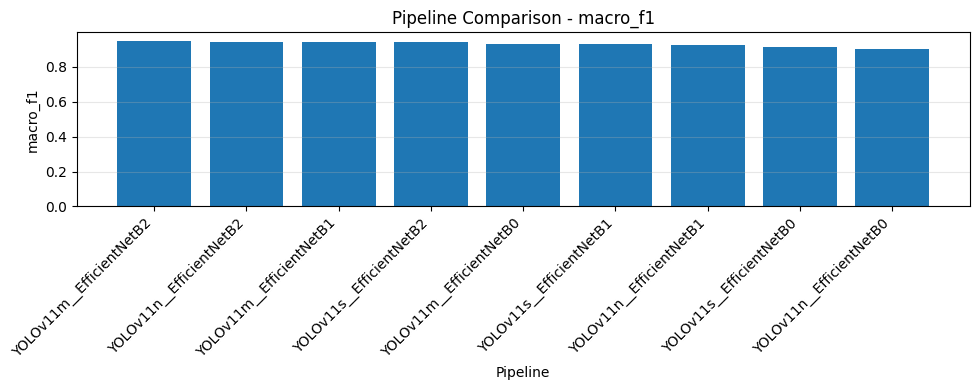

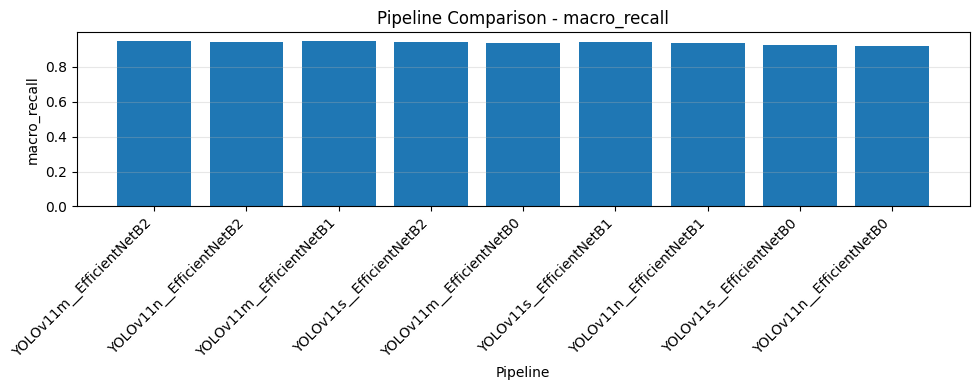

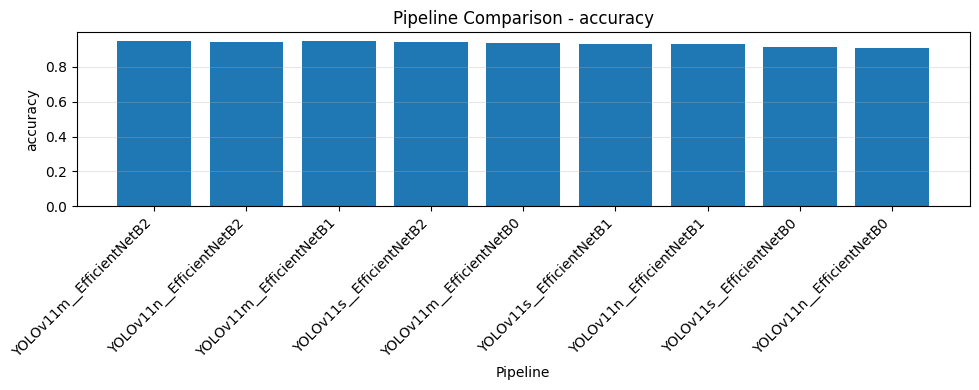

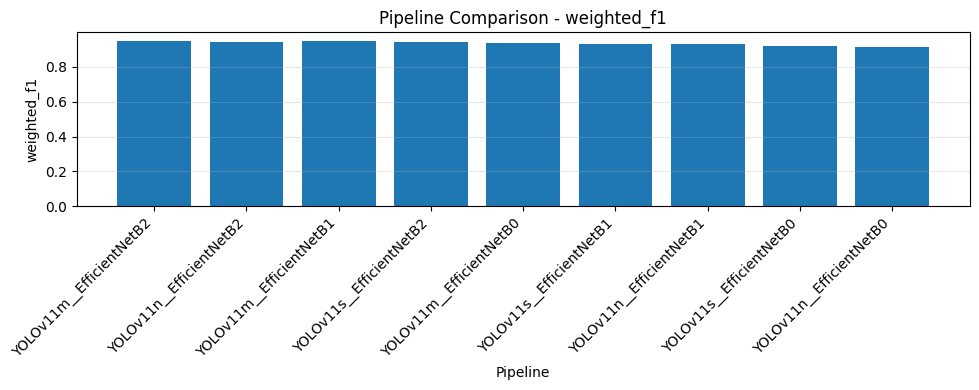

Best pipeline by macro_f1:


,pair_name,yolo_alias,cnn_alias,yolo_ckpt,cnn_ckpt,num_test_images,num_valid_predictions,accuracy,macro_precision,macro_recall,...,weighted_f1,agg_method,yolo_conf_start,yolo_conf_min,yolo_conf_step,full_cnn_disease_min_prob,bbox_expand_ratio,result_csv,pair_dir,timestamp
0,YOLOv11m__EfficientNetB2,YOLOv11m,EfficientNetB2,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,291,291,0.948454,0.949201,0.949326,...,0.94853,weighted,0.5,0.35,0.05,0.5,0.1,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,2026-04-26 11:16:54


In [10]:
# CELL 10: so sánh các pipeline

summary_path = PIPELINE_ROOT / "all_pipeline_summary.csv"
assert summary_path.exists(), f"Không thấy summary: {summary_path}"

summary_df = pd.read_csv(summary_path)

sort_cols = ["macro_f1", "macro_recall", "accuracy"]
summary_df = summary_df.sort_values(
    by=sort_cols,
    ascending=[False, False, False]
).reset_index(drop=True)

summary_df.to_csv(PIPELINE_ROOT / "all_pipeline_summary_sorted.csv", index=False, encoding="utf-8-sig")

display(summary_df)

for metric in ["macro_f1", "macro_recall", "accuracy", "weighted_f1"]:
    if metric in summary_df.columns:
        plt.figure(figsize=(10, 4))
        plt.bar(summary_df["pair_name"], summary_df[metric])
        plt.title(f"Pipeline Comparison - {metric}")
        plt.xlabel("Pipeline")
        plt.ylabel(metric)
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.savefig(PIPELINE_ROOT / f"comparison_{metric}.png", dpi=200, bbox_inches="tight")
        plt.show()

print("Best pipeline by macro_f1:")
display(summary_df.head(1))

In [11]:
# CELL 11: phân tích lỗi của pipeline tốt nhất

best_pair = summary_df.iloc[0]["pair_name"]
best_pair_dir = PIPELINE_ROOT / best_pair
pred_csv = best_pair_dir / "pipeline_predictions.csv"

assert pred_csv.exists(), f"Không thấy prediction CSV: {pred_csv}"

pred_df = pd.read_csv(pred_csv)

print("Best pair:", best_pair)
print("Total:", len(pred_df))
print("Correct:", int(pred_df["correct"].sum()))
print("Wrong:", int((pred_df["correct"] == 0).sum()))

print("\nAccuracy by true class:")
class_acc = (
    pred_df
    .groupby("true_class")["correct"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={"count": "num_samples", "sum": "num_correct", "mean": "accuracy"})
)
display(class_acc)

print("\nError cases:")
error_df = pred_df[pred_df["correct"] == 0].copy()
display(error_df[[
    "image_path",
    "true_class",
    "pred_class",
    "reason",
    "num_boxes",
    "conf_used",
    "full_cnn_class",
    "full_cnn_conf",
    "error"
]].head(50))

error_df.to_csv(best_pair_dir / "error_cases.csv", index=False, encoding="utf-8-sig")
class_acc.to_csv(best_pair_dir / "accuracy_by_class.csv", index=False, encoding="utf-8-sig")

print("Saved:")
print(best_pair_dir / "error_cases.csv")
print(best_pair_dir / "accuracy_by_class.csv")

Best pair: YOLOv11m__EfficientNetB2
Total: 291
Correct: 276
Wrong: 15

Accuracy by true class:


,true_class,num_samples,num_correct,accuracy
0,Anthracnose,54,51,0.944444
1,BacterialSpot,69,65,0.942029
2,Curl,54,53,0.981481
3,Healthy,34,32,0.941176
4,RingSpot,80,75,0.937500



Error cases:


,image_path,true_class,pred_class,reason,num_boxes,conf_used,full_cnn_class,full_cnn_conf,error
28,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,Anthracnose,yolo_boxes_cnn_weighted_vote,4,0.50,NaN,NaN,NaN
41,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,BacterialSpot,RingSpot,yolo_boxes_cnn_weighted_vote,4,0.50,NaN,NaN,NaN
54,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Healthy,no_yolo_box_after_conf_retry,0,0.35,BacterialSpot,0.966293,NaN
87,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Anthracnose,RingSpot,yolo_boxes_cnn_weighted_vote,1,0.50,NaN,NaN,NaN
112,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Healthy,no_yolo_box_full_cnn_healthy_or_low_conf,0,0.50,Healthy,0.982835,NaN
140,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Anthracnose,yolo_boxes_cnn_weighted_vote,3,0.50,NaN,NaN,NaN
178,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Anthracnose,yolo_boxes_cnn_weighted_vote,2,0.35,BacterialSpot,0.998853,NaN
201,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,RingSpot,Anthracnose,yolo_boxes_cnn_weighted_vote,2,0.50,NaN,NaN,NaN
203,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Anthracnose,RingSpot,yolo_boxes_cnn_weighted_vote,3,0.50,NaN,NaN,NaN
223,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,Curl,BacterialSpot,yolo_boxes_cnn_weighted_vote,1,0.35,BacterialSpot,0.754785,NaN


Saved:
/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11m__EfficientNetB2/error_cases.csv
/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/Pipeline_Evaluation/YOLOv11m__EfficientNetB2/accuracy_by_class.csv
